<div class="alert alert-info" role="alert" style="padding:20px; margin-bottom:16px;">
  <div style="text-align:center;">
    <h1 style="margin:0;">Exploratory Data Analysis</h1>
    <div style="font-size:18px; margin-top:4px;">Amazing International Airlines Inc.</div>
    <div style="font-size:18px; margin-top:4px;">Clustering - Value Based</div>
    <hr style="margin:12px auto; width:220px;">
    <div style="font-size:14px; color:#6c757d;">Group 92 • Notebook • 2025/2026</div>
  </div>
</div>


This Project was done by:


Student Name    -   Mehmet Karaca;
student id      -   20250344;
contact email   -   20250344@novaims.unl.pt

Student Name    -   Duarte Gomes;
student id      -   20250017;
contact email   -   20250017@novaims.unl.pt

Student Name    -   Esra Salhi
student id      -   20250537
contact email   -   20250537@novaims.unl.pt

## Table of Contents



Add some contents here



# 1 Introduction <a id="introduction"></a>


## 1.1. Importing Libraries <a id="importing-libraries"></a>


In [41]:
# --- Standard Imports
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import matplotlib
import math
import matplotlib as mpl
import matplotlib.cm as cm
from cycler import cycler
import geopandas as gpd
from matplotlib.lines import Line2D
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

In [2]:
# Plot style configuration (unified look)
# Keeps logic intact; only global appearance defaults are set.

# Accessible, consistent palette
_palette = sns.color_palette("Set1", 10)
_palette_hex = _palette.as_hex()

# Seaborn / Matplotlib defaults
sns.set_theme(style="whitegrid", context="notebook", palette=_palette)
mpl.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#333333',
    'axes.titleweight': 'semibold',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.grid': True,
    'grid.color': '#EAEAEA',
    'grid.linestyle': '-',
    'grid.alpha': 0.6,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.frameon': True,
    'legend.framealpha': 0.9,
    'legend.borderpad': 0.4,
    'legend.loc': 'best',
    'lines.linewidth': 2.0,
    'axes.prop_cycle': cycler('color', _palette_hex),
})


def make_palette_map(categories, palette_name="Set1", n_colors=None, as_hex=False):
    """
    Simple: returns (palette_map, palette_list).
    - categories: iterable (keeps first-seen order, coerces to str)
    - palette_name: seaborn palette name
    - n_colors: optional override (defaults to max(len(categories), 3))
    - as_hex: if True, return palette_map with hex strings
    """
    cats = [str(c) for c in dict.fromkeys(categories)]          # unique keep-order
    n_colors = n_colors or max(len(cats), 3)
    palette = sns.color_palette(palette_name, n_colors)
    palette_map = {cat: palette[i % len(palette)] for i, cat in enumerate(cats)}
    if as_hex:
        return {k: matplotlib.colors.to_hex(v) for k, v in palette_map.items()}, palette
    return palette_map, palette



# Plotly defaults (to align with seaborn/matplotlib)
px.defaults.template = 'plotly_white'
px.defaults.color_discrete_sequence = _palette_hex
px.defaults.color_continuous_scale = 'Cividis'
px.defaults.width = 900
px.defaults.height = 500


## 1.2. Loading and Reading Data <a id="loading-and-reading-data"></a>

In [3]:
# directory with raw CSV files
data_dir = Path("../data/cleanAndFeatureEngineered")

# list all CSV files
csv_files = list(data_dir.glob("*.csv"))
print(f"Found CSV files: {[f.name for f in csv_files]}")

Found CSV files: ['DM_AIAI_CustomerDB_Cleaned_Featured.csv', 'DM_AIAI_FlightsDB_Cleaned_Featured.csv']


In [4]:
# specify the files we want to load
customers_file = data_dir / "DM_AIAI_CustomerDB_Cleaned_Featured.csv"
flights_file   = data_dir / "DM_AIAI_FlightsDB_Cleaned_Featured.csv"

# load them with pandas
customers = pd.read_csv(customers_file)
flights   = pd.read_csv(flights_file)

print("Customers shape:", customers.shape)
print("Flights shape:", flights.shape)

Customers shape: (16375, 31)
Flights shape: (596664, 11)


## 1.3. Brief Preliminary Analysis <a id="brief-preliminary-analysis"></a>

In [5]:
customers.columns

Index(['Loyalty#', 'First Name', 'Last Name', 'Customer Name', 'Country',
       'Province or State', 'City', 'Latitude', 'Longitude', 'Postal code',
       'Gender', 'Education', 'Location Code', 'Income', 'Marital Status',
       'LoyaltyStatus', 'EnrollmentDateOpening', 'CancellationDate',
       'Customer Lifetime Value', 'EnrollmentType', 'IsActive',
       'CustomerTenureDays', 'total_flights', 'total_flights_with_companions',
       'total_distance', 'total_points_accumulated', 'total_points_redeemed',
       'total_cost_redeemed', 'average_distance_per_flight',
       'points_redemption_ratio', 'companion_flight_ratio'],
      dtype='object')

In [6]:
flights.columns

Index(['Loyalty#', 'Year', 'Month', 'YearMonthDate', 'NumFlights',
       'NumFlightsWithCompanions', 'DistanceKM', 'PointsAccumulated',
       'PointsRedeemed', 'DollarCostPointsRedeemed', 'Season'],
      dtype='object')

In [7]:
customers.describe(include='number')

,Loyalty#,Latitude,Longitude,Income,Customer Lifetime Value,IsActive,CustomerTenureDays,total_flights,total_flights_with_companions,total_distance,total_points_accumulated,total_points_redeemed,total_cost_redeemed,average_distance_per_flight,points_redemption_ratio,companion_flight_ratio
count,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000
mean,549432.932641,47.174418,-91.838613,37721.547359,7982.088433,0.874931,1104.017282,160.315874,34.035603,289943.099212,28988.602947,8601.144116,84.999084,8053.974942,0.286192,0.219317
std,258720.547621,3.306921,22.245806,30342.177810,6841.119253,0.330807,741.228136,67.910430,22.216511,162257.383492,16223.028595,8707.423785,86.110464,4507.149549,0.410727,0.128048
min,100018.000000,42.984924,-135.056840,0.000000,1898.010000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,326276.000000,44.231171,-120.237660,0.000000,3979.390000,1.000000,384.000000,121.640000,16.000000,153607.450000,15356.795000,0.000000,0.000000,4266.875000,0.000000,0.150407
50%,550434.000000,46.087818,-79.383186,34115.000000,5781.020000,1.000000,1032.000000,173.400000,35.000000,333555.500000,33350.310000,6627.000000,65.000000,9265.430000,0.217670,0.221622
75%,771330.000000,49.282730,-74.596184,62375.000000,8936.970000,1.000000,1754.000000,213.620000,50.000000,414067.300000,41400.130000,13663.850000,134.950000,11501.870000,0.420562,0.288889
max,999986.000000,60.721188,-52.712578,99981.000000,83325.380000,1.000000,2466.000000,340.000000,119.000000,712729.600000,71264.460000,57527.800000,572.000000,19798.040000,16.125899,1.000000


# 2. Clustering - Demographic <a class="anchor" id="data-validity-checks"></a>

We will do now the Clustering. This notebook will focus on Value Based Perspective for Clustering

We have to decide, which features we will use for Clustering from Demographic Perspective. 
We will use the following features for Clustering from Demographic Perspective:


- Country
- Proivince or State
- City
- Postal Code
- Location Code
- Latitude, Longitude
- Gender
- Education
- Income
- Maritial Status


In [8]:
# Demographic based features selection
customers[['Country','Province or State','City','Postal code','Location Code','Latitude','Longitude','Gender','Education','Income','Marital Status']]

,Country,Province or State,City,Postal code,Location Code,Latitude,Longitude,Gender,Education,Income,Marital Status
0,Canada,Ontario,Toronto,M2Z 4K1,Urban,43.653225,-79.383186,female,Bachelor,70146.0,Married
1,Canada,Alberta,Edmonton,T3G 6Y6,Rural,53.544388,-113.490930,male,College,0.0,Divorced
2,Canada,British Columbia,Vancouver,V6E 3D9,Urban,49.282730,-123.120740,male,College,0.0,Single
3,Canada,Ontario,Toronto,P1W 1K4,Suburban,43.653225,-79.383186,male,College,0.0,Single
4,Canada,Quebec,Hull,J8Y 3Z5,Suburban,45.428730,-75.713364,male,Bachelor,97832.0,Married
...,...,...,...,...,...,...,...,...,...,...,...
16370,Canada,British Columbia,Vancouver,V6E 3Z3,Rural,49.282730,-123.120740,female,College,0.0,Married
16371,Canada,Saskatchewan,Regina,S1J 3C5,Rural,50.445210,-104.618900,female,Bachelor,78310.0,Married
16372,Canada,British Columbia,Vancouver,V5R 1W3,Urban,49.282730,-123.120740,male,College,0.0,Single
16373,Canada,Quebec,Montreal,H2Y 4R4,Urban,45.501690,-73.567253,male,Bachelor,58958.0,Married


## 2.1 Splitting features names into groups

In [9]:
demog_cols = ['Country','Province or State','City','Postal code','Location Code','Latitude','Longitude','Gender','Education','Income','Marital Status']

df_demog = customers[demog_cols].copy()

We won't consider Country, since all customers are from Canada, and Postal Code because it is too specific and almost unique for each customer.

In [10]:
metric_features = ['Income', 'Latitude', 'Longitude']
non_metric_features = ['Gender', 'Education', 'Marital Status','Province or State','City','Location Code']

## 2.2 Encoding

In [11]:
# create the OneHotEncoder
ohc = OneHotEncoder(sparse_output=False, drop="first")

# Apply the encoder to the non metric features
ohc_array = ohc.fit_transform(df_demog[non_metric_features])

# names of the new columns
ohc_cols = ohc.get_feature_names_out(non_metric_features)

# array to df
ohc_df = pd.DataFrame(
    ohc_array,
    index=df_demog.index,
    columns=ohc_cols
)

# non-metric with metric features
df_ready = pd.concat(
    [df_demog[metric_features], ohc_df],
    axis=1
)

In [12]:
print(df_ready.head())
print(df_ready.info())

    Income   Latitude   Longitude  Gender_male  Education_College  \
0  70146.0  43.653225  -79.383186          0.0                0.0   
1      0.0  53.544388 -113.490930          1.0                1.0   
2      0.0  49.282730 -123.120740          1.0                1.0   
3      0.0  43.653225  -79.383186          1.0                1.0   
4  97832.0  45.428730  -75.713364          1.0                0.0   

   Education_Doctor  Education_High School or Below  Education_Master  \
0               0.0                             0.0               0.0   
1               0.0                             0.0               0.0   
2               0.0                             0.0               0.0   
3               0.0                             0.0               0.0   
4               0.0                             0.0               0.0   

   Marital Status_Married  Marital Status_Single  ...  City_Tremblant  \
0                     1.0                    0.0  ...             0.0   


## 2.3 Scaling

In [13]:
scaler = StandardScaler()
X = scaler.fit_transform(df_ready)
X_df = pd.DataFrame(X, columns=df_ready.columns, index=df_ready.index)
print(X_df)

         Income  Latitude  Longitude  Gender_male  Education_College  \
0      1.068659 -1.064828   0.559917    -0.995430          -0.582545   
1     -1.243243  1.926313  -0.973351     1.004591           1.716605   
2     -1.243243  0.637565  -1.406246     1.004591           1.716605   
3     -1.243243 -1.064828   0.559917     1.004591           1.716605   
4      1.981146 -0.527905   0.724889     1.004591          -0.582545   
...         ...       ...        ...          ...                ...   
16370 -1.243243  0.637565  -1.406246    -0.995430           1.716605   
16371  1.337732  0.989105  -0.574521    -0.995430          -0.582545   
16372 -1.243243  0.637565  -1.406246     1.004591           1.716605   
16373  0.699920 -0.505842   0.821365     1.004591          -0.582545   
16374  0.699920  0.822760  -0.238244    -0.995430          -0.582545   

       Education_Doctor  Education_High School or Below  Education_Master  \
0             -0.213677                       -0.221224   

## 2.4 Defining the number of Clusters

For the clustering we will need to define the clustering algorithm and the number of clusters.

### Elbow Method

In [14]:
range_clusters = range(1,10)

c:\Users\Duarte\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Duarte\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Duarte\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Duarte\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^

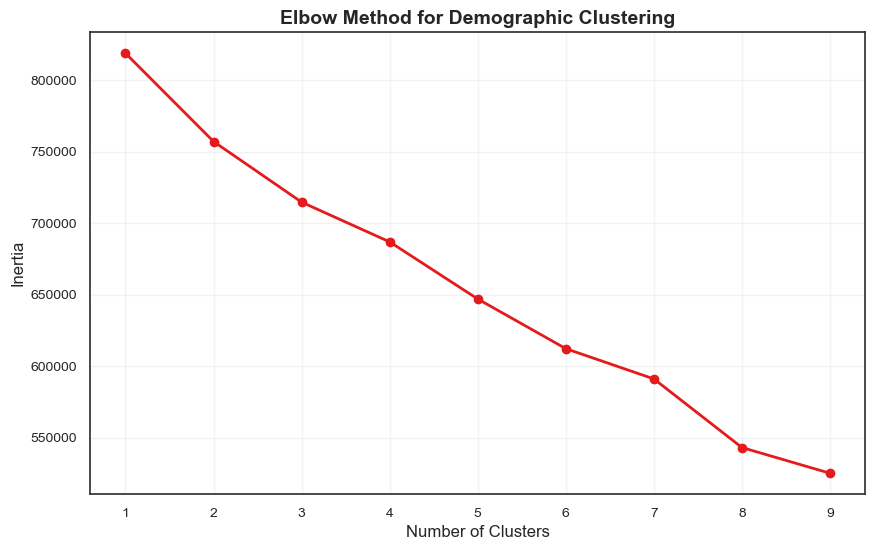

In [15]:
inertia = []
K = range_clusters

for k in K:
    km = KMeans(n_clusters=k, init='k-means++', n_init=15, random_state=1)
    km.fit(X)
    inertia.append(km.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Demographic Clustering")
plt.show()

### Silhouette Coefficient

For n_clusters = 2, the average silhouette_score is : 0.6344301697886608
For n_clusters = 3, the average silhouette_score is : 0.6437660016784755
For n_clusters = 4, the average silhouette_score is : 0.6601210711862457
For n_clusters = 5, the average silhouette_score is : 0.6599909041861141
For n_clusters = 6, the average silhouette_score is : 0.6618701516191543
For n_clusters = 7, the average silhouette_score is : 0.6478798734436096
For n_clusters = 8, the average silhouette_score is : 0.6487416487957037
For n_clusters = 9, the average silhouette_score is : 0.6496616238432256


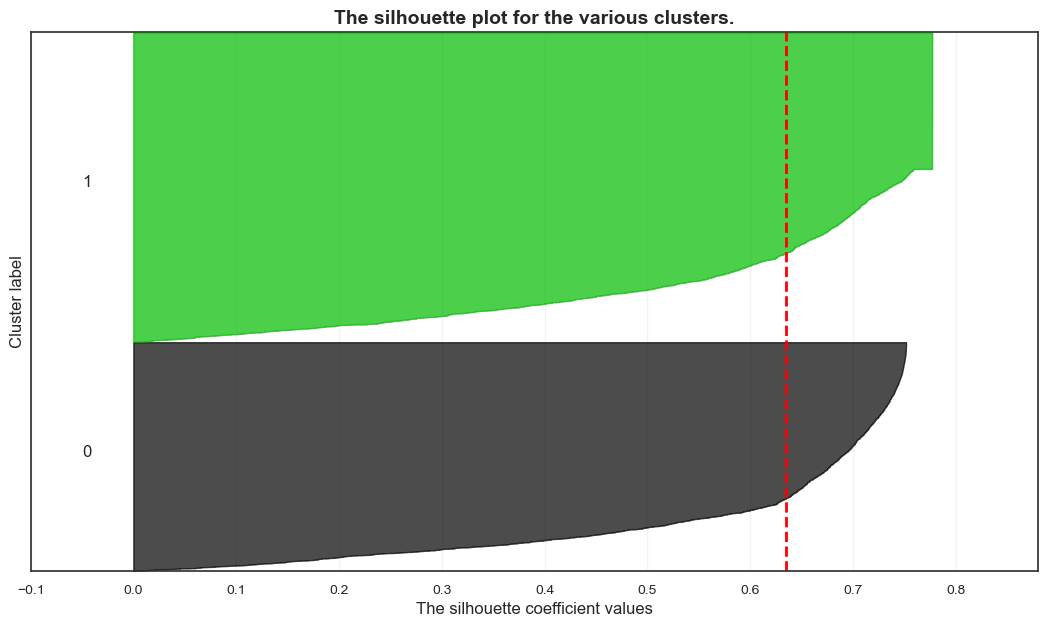

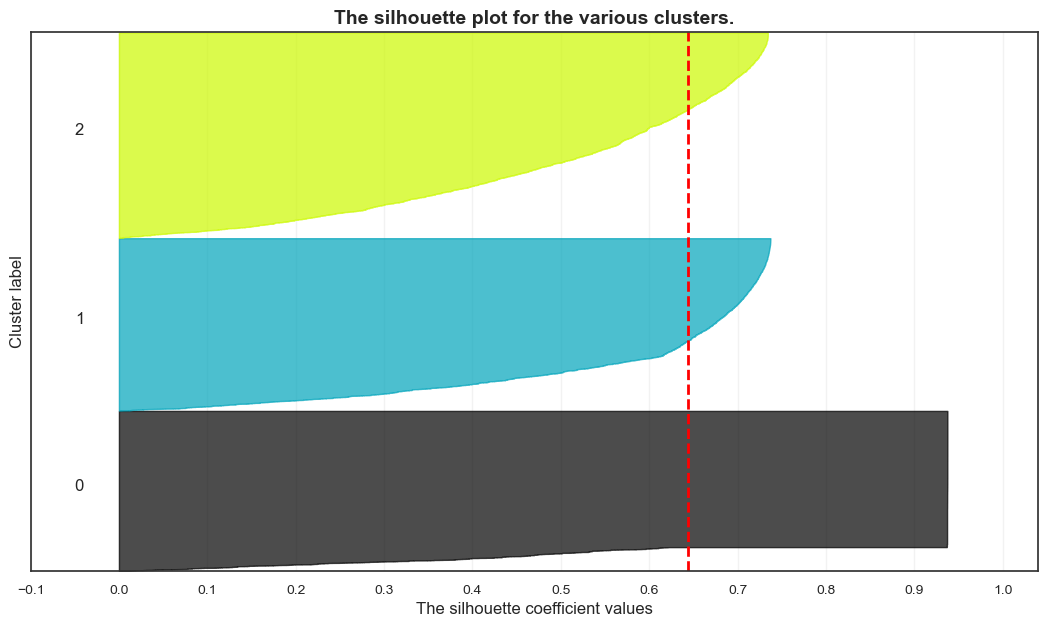

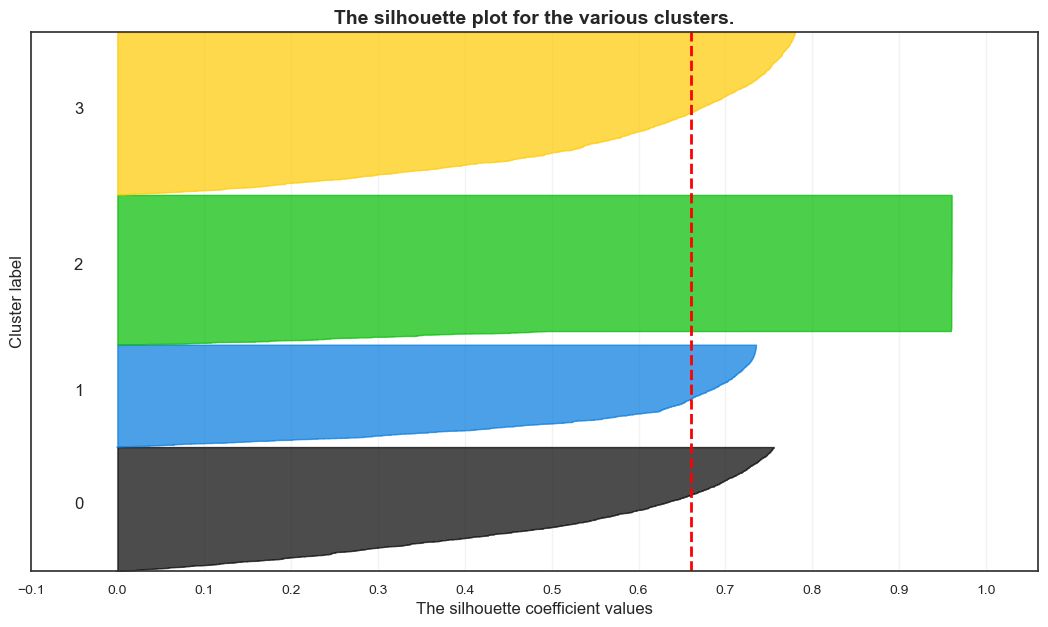

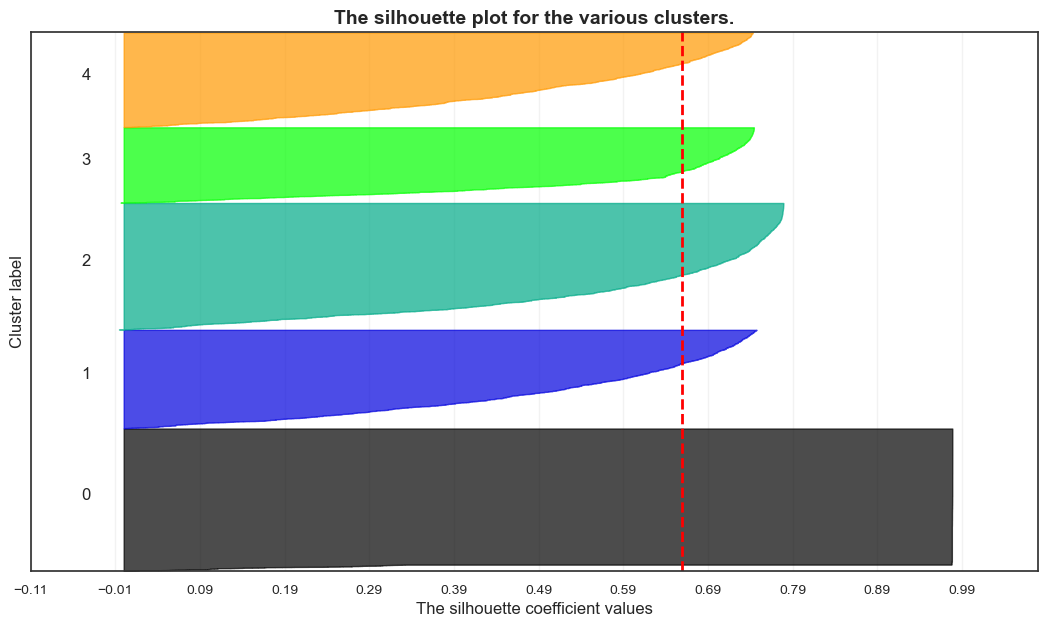

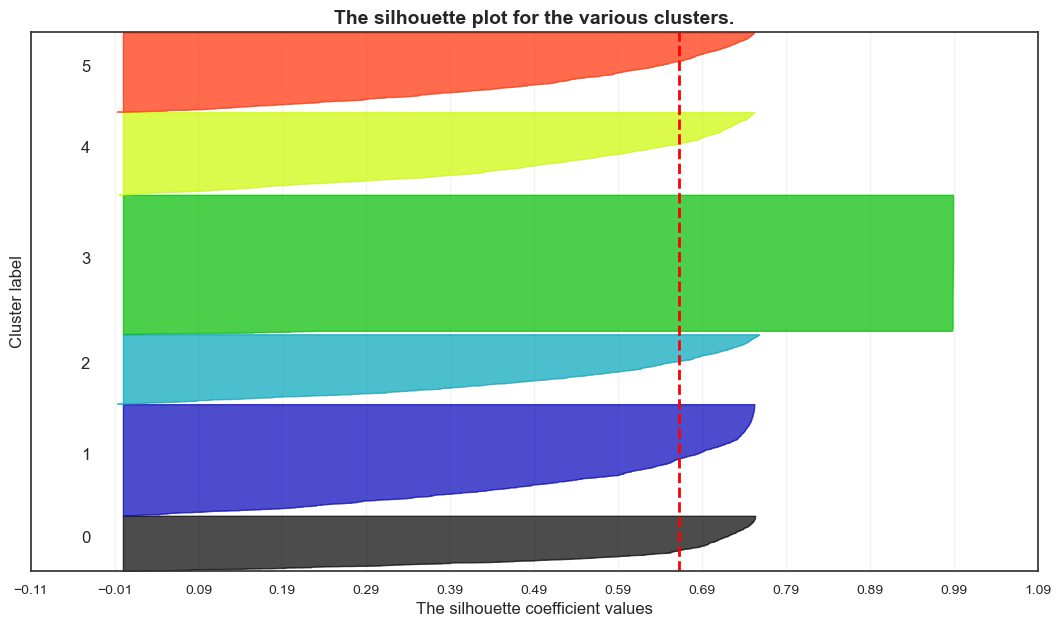

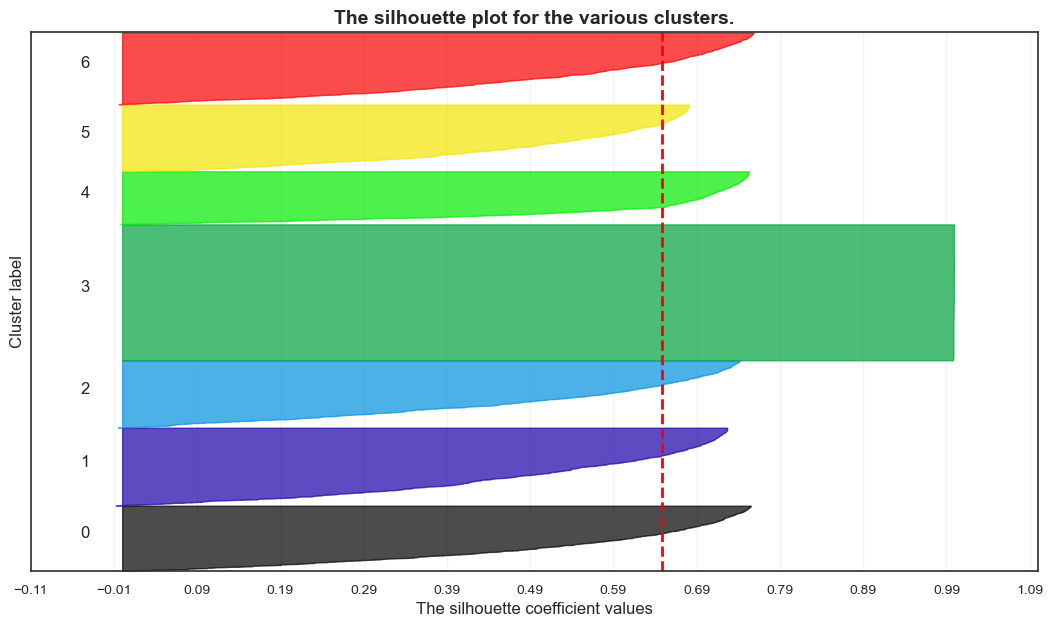

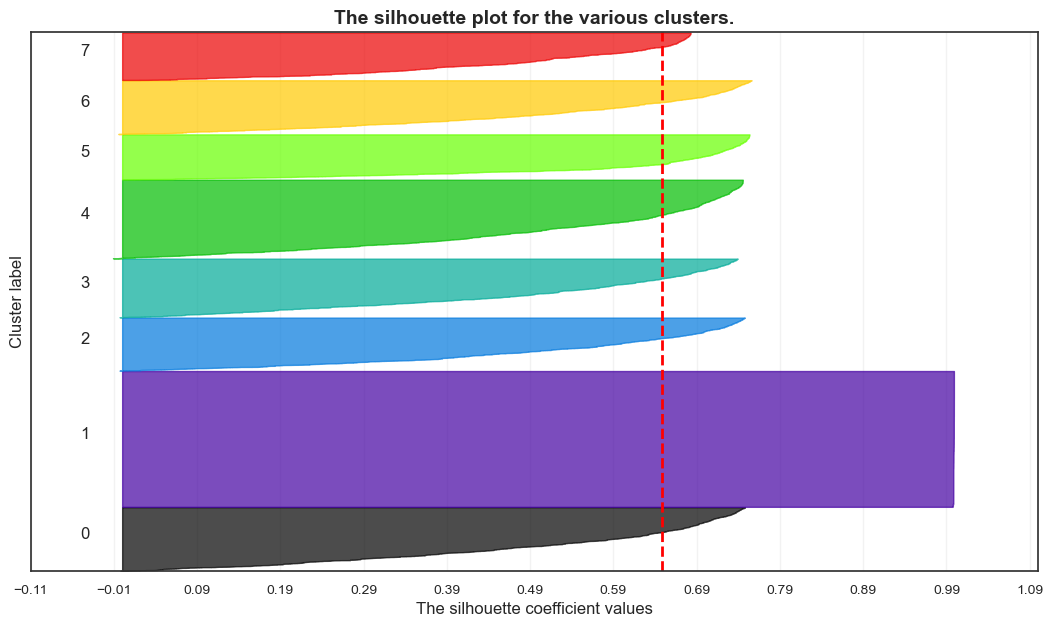

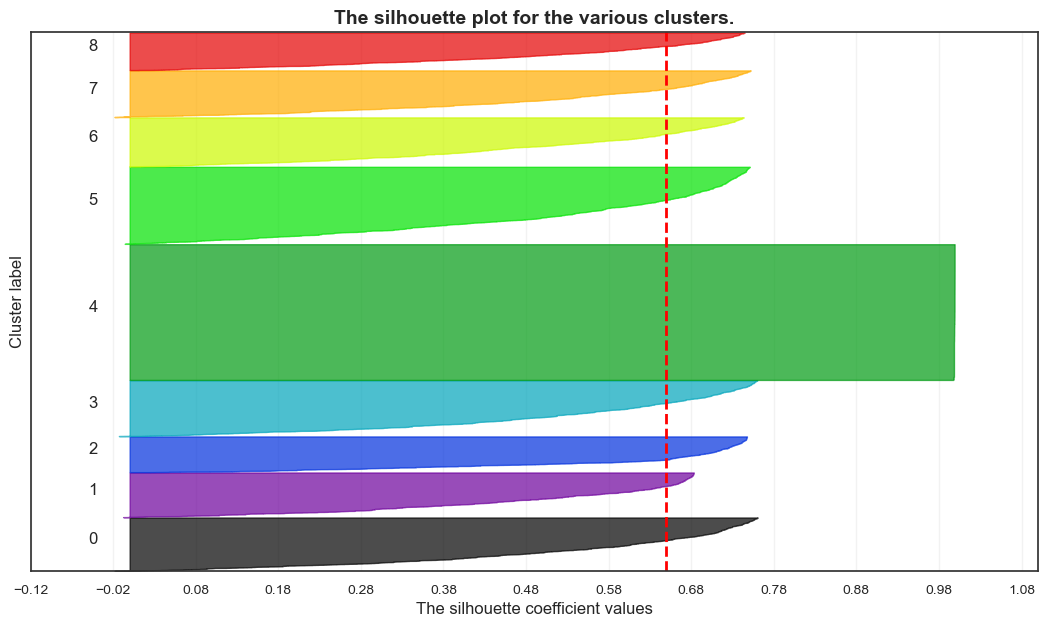

In [ ]:
# Storing average silhouette metric
avg_silhouette = []
for nclus in range_clusters:
    # Skip nclus == 1
    if nclus == 1:
        continue
    
    # Create a figure
    fig = plt.figure(figsize=(13, 7))

    # Initialize the KMeans object with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    kmclust = KMeans(n_clusters=nclus, init='k-means++', n_init=15, random_state=1)
    cluster_labels = kmclust.fit_predict(df_demog[metric_features])

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed clusters
    silhouette_avg = silhouette_score(df_demog[metric_features], cluster_labels)
    avg_silhouette.append(silhouette_avg)
    print(f"For n_clusters = {nclus}, the average silhouette_score is : {silhouette_avg}")

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(df_demog[metric_features], cluster_labels)

    y_lower = 10
    for i in range(nclus):
        # Aggregate the silhouette scores for samples belonging to cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        
        # Get y_upper to demarcate silhouette y range size
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        
        # Filling the silhouette
        color = cm.nipy_spectral(float(i) / nclus)
        plt.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        # Label the silhouette plots with their cluster numbers at the middle
        plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    plt.title("The silhouette plot for the various clusters.")
    plt.xlabel("The silhouette coefficient values")
    plt.ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    plt.axvline(x=silhouette_avg, color="red", linestyle="--")
    
    # The silhouette coefficient can range from -1, 1
    xmin, xmax = np.round(sample_silhouette_values.min() -0.1, 2), np.round(sample_silhouette_values.max() + 0.1, 2)
    plt.xlim([xmin, xmax])
    
    # The (nclus+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    plt.ylim([0, len(df_demog[metric_features]) + (nclus + 1) * 10])

    plt.yticks([])  # Clear the yaxis labels / ticks
    plt.xticks(np.arange(xmin, xmax, 0.1))

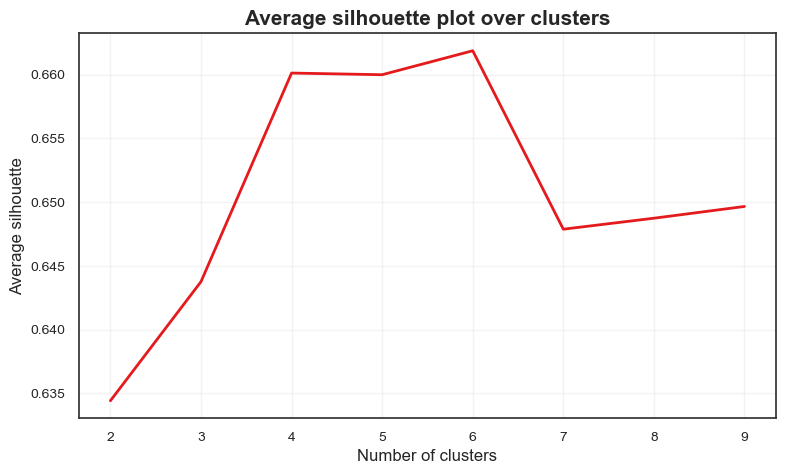

In [ ]:
# The average silhouette plot
# The inertia plot
plt.figure(figsize=(9,5))

plt.plot(range_clusters[1:],
         avg_silhouette)    

plt.ylabel("Average silhouette")
plt.xlabel("Number of clusters")
plt.title("Average silhouette plot over clusters", size=15)
plt.show()

### Dendogram

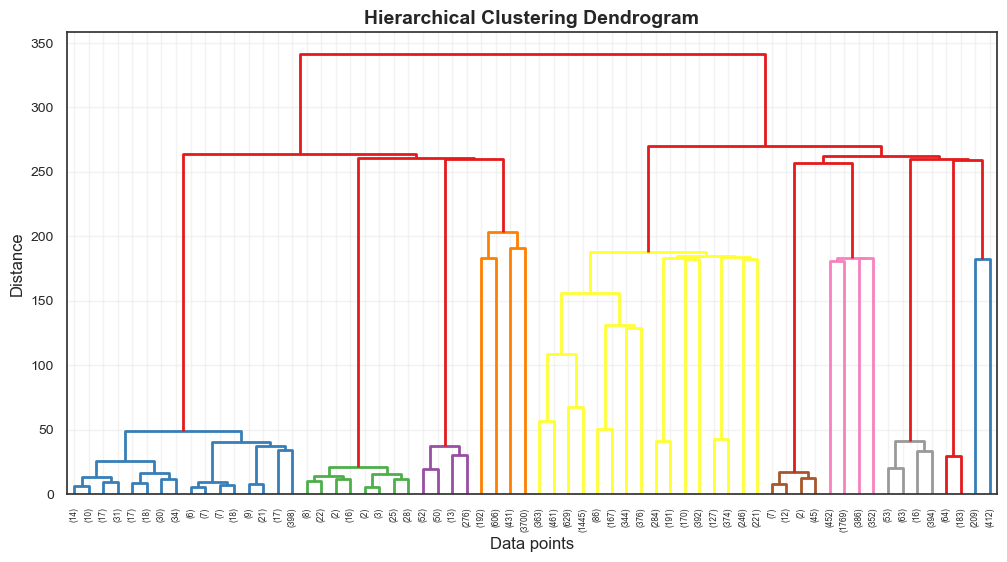

In [34]:
# Perform hierarchical clustering using Ward linkage
Z = linkage(X, method='ward')  

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)  # show last 5 merges
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data points")
plt.ylabel("Distance")
plt.show()

From the analysis done previously we will use 6 clusters

In [19]:
# number of clusters
k = 6

## 2.5 Hierachical Clustering

In [35]:
hier = AgglomerativeClustering(
    n_clusters=k,
    linkage='ward',         # same method used in the dendrogram
    metric='euclidean'      # distance measure
)

hier_labels = hier.fit_predict(X_df)
hier_labels

array([2, 1, 1, ..., 1, 4, 3])

In [36]:
customers["hier_cluster"] = hier_labels
customers["hier_cluster"].value_counts()

hier_cluster
2    5876
1    5320
4    3025
0    1394
3     654
5     106
Name: count, dtype: int64

## 2.6 K-Means

In [20]:
km = KMeans(n_clusters=k, init='k-means++', n_init=15, random_state=1)
km_labels = km.fit_predict(X_df)
km_labels   

array([3, 2, 2, ..., 2, 1, 0], dtype=int32)

In [21]:
# add the cluster to the dataframe
customers['demo_cluster'] = km_labels
customers

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,...,total_flights,total_flights_with_companions,total_distance,total_points_accumulated,total_points_redeemed,total_cost_redeemed,average_distance_per_flight,points_redemption_ratio,companion_flight_ratio,demo_cluster
0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,...,235.64,53,507054.9,50699.39,13517.9,134.6,14084.86,0.266628,0.264207,3
1,549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,...,292.60,30,426827.4,42672.54,22457.8,221.4,11856.32,0.526282,0.102529,2
2,429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,...,142.60,37,238376.1,23832.41,5479.6,53.2,6621.56,0.229922,0.259467,2
3,608370,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,...,197.00,55,386029.3,38595.63,16331.5,162.2,10723.04,0.423144,0.279188,3
4,530508,Claire,Latting,Claire Latting,Canada,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,...,187.00,59,369242.6,36916.56,0.0,0.0,10256.74,0.000000,0.315508,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16370,823768,Mandy,Sammarco,Mandy Sammarco,Canada,British Columbia,Vancouver,49.282730,-123.120740,V6E 3Z3,...,168.00,15,414936.3,41487.73,0.0,0.0,11526.01,0.000000,0.089286,2
16371,680886,Jamee,Ahlm,Jamee Ahlm,Canada,Saskatchewan,Regina,50.445210,-104.618900,S1J 3C5,...,265.00,59,362649.6,36253.76,16434.8,162.7,10073.60,0.453327,0.222642,2
16372,776187,Janina,Lumb,Janina Lumb,Canada,British Columbia,Vancouver,49.282730,-123.120740,V5R 1W3,...,235.64,44,486378.9,48628.99,15733.0,156.3,13510.53,0.323531,0.173913,2
16373,615459,Dannie,Paplow,Dannie Paplow,Canada,Quebec,Montreal,45.501690,-73.567253,H2Y 4R4,...,53.00,22,62696.0,6266.00,5247.0,52.0,1741.56,0.837376,0.415094,1


In [22]:
# number of customers per cluster
customers['demo_cluster'].value_counts().sort_values(ascending=False)

demo_cluster
3    5974
2    5762
1    3212
0     654
5     526
4     247
Name: count, dtype: int64

In [23]:
# check 
len(X_df) == len(customers)

True

### K-Means Analysis

In [24]:
# income
customers.groupby('demo_cluster')['Income'].describe()

,count,mean,std,min,25%,50%,75%,max
demo_cluster,,,,,,,,
0,654.0,36188.443425,30022.335772,0.0,0.0,31509.0,59765.50,99874.0
1,3212.0,37754.398817,30179.172354,0.0,10230.5,33808.5,61353.25,99875.0
2,5762.0,37778.520132,30492.269854,0.0,0.0,34496.5,62587.75,99981.0
3,5974.0,37609.058587,30365.220421,0.0,0.0,33880.0,62459.50,99981.0
4,247.0,37150.809717,29870.630694,0.0,0.0,34430.0,60548.00,95765.0
5,526.0,40348.608365,30013.007213,0.0,15555.0,38748.0,65294.50,99612.0


In [25]:
# gender
customers.groupby('demo_cluster')['Gender'].value_counts(normalize=True)

demo_cluster  Gender
0             female    0.533639
              male      0.466361
1             female    0.500311
              male      0.499689
2             female    0.510760
              male      0.489240
3             male      0.506528
              female    0.493472
4             male      0.518219
              female    0.481781
5             male      0.507605
              female    0.492395
Name: proportion, dtype: float64

In [26]:
# education
customers.groupby('demo_cluster')['Education'].value_counts(normalize=True)

demo_cluster  Education           
0             Bachelor                0.608563
              College                 0.261468
              High School or Below    0.058104
              Doctor                  0.045872
              Master                  0.025994
1             Bachelor                0.627958
              College                 0.249377
              Doctor                  0.047323
              High School or Below    0.046389
              Master                  0.028954
2             Bachelor                0.624436
              College                 0.256508
              High School or Below    0.047032
              Doctor                  0.041826
              Master                  0.030198
3             Bachelor                0.624037
              College                 0.254268
              High School or Below    0.045865
              Doctor                  0.044694
              Master                  0.031135
4             Bachelor   

In [27]:
# Martial Status
customers.groupby('demo_cluster')['Marital Status'].value_counts(normalize=True)

demo_cluster  Marital Status
0             Married           0.579511
              Single            0.270642
              Divorced          0.149847
1             Married           0.583126
              Single            0.266812
              Divorced          0.150062
2             Married           0.583825
              Single            0.268483
              Divorced          0.147692
3             Married           0.581687
              Single            0.269836
              Divorced          0.148477
4             Married           0.562753
              Single            0.271255
              Divorced          0.165992
5             Married           0.581749
              Single            0.249049
              Divorced          0.169202
Name: proportion, dtype: float64

In [28]:
# Province
customers.groupby('demo_cluster')['Province or State'].value_counts(normalize=True).head(20)

demo_cluster  Province or State   
0             Manitoba                1.000000
1             Quebec                  1.000000
2             British Columbia        0.743492
              Alberta                 0.170253
              Saskatchewan            0.067858
              Yukon                   0.018396
3             Ontario                 0.885002
              New Brunswick           0.103950
              Prince Edward Island    0.011048
4             Newfoundland            1.000000
5             Nova Scotia             1.000000
Name: proportion, dtype: float64

In [29]:
# City
customers.groupby('demo_cluster')['City'].value_counts(normalize=True).head(20)

demo_cluster  City          
0             Winnipeg          1.000000
1             Montreal          0.623910
              Quebec City       0.146326
              Tremblant         0.120174
              Hull              0.109589
2             Vancouver         0.437348
              Whistler          0.099618
              Edmonton          0.085734
              Dawson Creek      0.074800
              Regina            0.067858
              Victoria          0.065429
              West Vancouver    0.053107
              Calgary           0.033322
              Banff             0.031760
              Peace River       0.019438
              Whitehorse        0.018396
              Kelowna           0.013190
3             Toronto           0.549381
              Ottawa            0.083863
              Trenton           0.079511
Name: proportion, dtype: float64

In [30]:
# location code
customers.groupby('demo_cluster')['Location Code'].value_counts(normalize=True)

demo_cluster  Location Code
0             Rural            0.347095
              Suburban         0.337920
              Urban            0.314985
1             Rural            0.347447
              Suburban         0.332814
              Urban            0.319738
2             Suburban         0.340680
              Rural            0.332871
              Urban            0.326449
3             Suburban         0.339304
              Urban            0.332775
              Rural            0.327921
4             Rural            0.348178
              Suburban         0.348178
              Urban            0.303644
5             Suburban         0.353612
              Rural            0.334601
              Urban            0.311787
Name: proportion, dtype: float64

## 2.7 Hierarchical Clustering vs K-Means Clustering

In [37]:
pd.crosstab(customers['demo_cluster'], customers['hier_cluster'])

hier_cluster,0,1,2,3,4,5
demo_cluster,,,,,,
0,0,0,0,654,0,0
1,0,0,253,0,2959,0
2,0,5320,336,0,0,106
3,621,0,5287,0,66,0
4,247,0,0,0,0,0
5,526,0,0,0,0,0


## 2.8 Density based Clustering

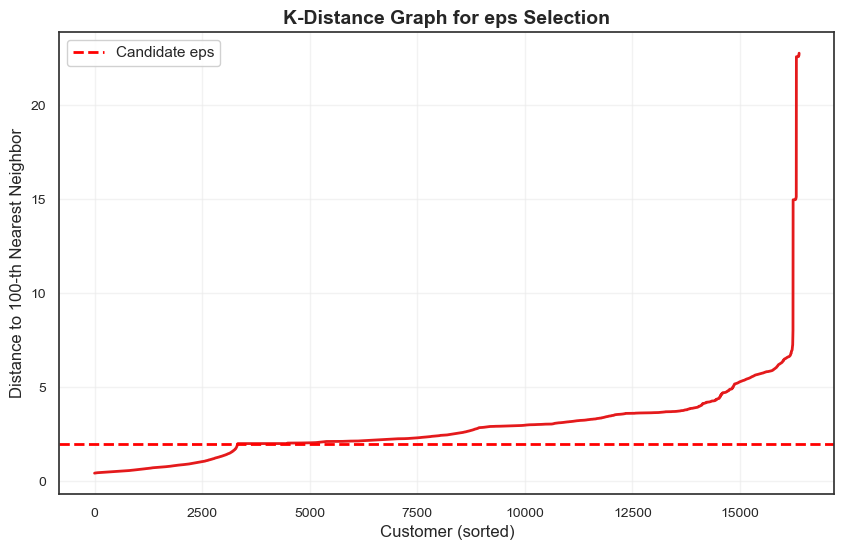

In [ ]:
# 1. Use the scaled demographic features
X_demog = X_df  # X_df should be your fully prepared and scaled feature matrix

# 2. Define k for nearest neighbors (rule of thumb: 2 * n_features, but you can adjust)
n_features = X_demog.shape[1]
k_neighbors = 2 * n_features

neigh = NearestNeighbors(n_neighbors=k_neighbors)
neigh.fit(X_demog)

# 3. Get distances to the k-th nearest neighbor
distances, indices = neigh.kneighbors(X_demog)

# distances is (n_samples x k_neighbors); we take the k-th neighbor (last column)
distances = distances[:, -1]

# Sort distances in ascending order
distances = np.sort(distances)

# 4. Plot the K-distance graph
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title("K-Distance Graph for eps Selection")
plt.xlabel("Customer (sorted)")
plt.ylabel(f"Distance to {k_neighbors}-th Nearest Neighbor")
plt.grid(True)

# Draw a candidate eps line (adjust after you see the curve)
plt.axhline(y=2, color='r', linestyle='--', label='Candidate eps')

plt.legend()
plt.show()

In [44]:
# Choose eps based on the K-distance graph
eps_value = 3.2
min_samples = k_neighbors 

dbscan = DBSCAN(
    eps=eps_value,
    min_samples=min_samples,
    metric='euclidean'
)

# Fit DBSCAN and get cluster labels
db_labels = dbscan.fit_predict(X_demog)

# Inspect cluster distribution (-1 means noise)
cluster_counts = pd.Series(db_labels).value_counts().sort_index()
print(cluster_counts)


-1     3123
 0     2898
 1     2224
 2      252
 3      411
 4     1769
 5      331
 6      424
 7      283
 8      510
 9      168
 10     569
 11     226
 12     398
 13     266
 14     296
 15     153
 16     439
 17     182
 18     461
 19     318
 20     307
 21     130
 22     120
 23     117
Name: count, dtype: int64
